<a href="https://colab.research.google.com/github/CSujay01/av-vlm-rule-compliance-analysis/blob/main/av_obstacle__negotiation__rule_compliance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***AUTONOMOUS VEHICLES_OBSTACLE NEGOTIATION_&_RULE COMPLIANCE ANALYSIS***

Author: Sujay Chaudhari
Date: MARCH-APRIL 2026  
Based on real-world labelling-annotation-quality work on **NVIDIA perception data**

***INTRODUCTION***

During my work annotating AV perception data (ego-motion, VLM, deep maps) for Level 4 autonomous driving, I observed recurring patterns in model behavior at complex intersections. This study documents an independent analysis of those patterns, focusing on rule-compliance failures and obstacle negotiation issues.

***METHODOLOGY***
Although the original data is proprietary, I applied the following approach:
1. Identify high-disengagement scenarios from labelling-annotation cases.
2. Categorize failures: "failure to yield", "late braking", "path ambiguity near obstacles".
3. Compare against expected rule set (traffic lights, stop signs, right-of-way).
4. Document systemic gaps, not single-frame errors.
The same methodology is demonstrated below using a public dataset.

***KEY FINDINGS***

**Observed failure categories (qualitative, from real annotation work — no proprietary data):**

Across the high-disengagement cases I reviewed at complex / occluded intersections, three
failure categories recurred, in roughly this order of frequency:

1. **Obstacle negotiation around parked or egressing vehicles - most common (about half the
   cases I looked at, roughly 10 of ~20).** When negotiating parked vehicles, or vehicles
   pulling out of a parking spot near the intersection, the system's focus shifted to the
   surrounding vehicle's behaviour before resolving the traffic-control state. This led to
   delayed or incorrect stopping decisions and, in turn, traffic-signal or stop-sign
   violations.

2. **Degraded perception of traffic controls under glare.** Where the control itself was
   washed out a traffic light glaring, or a stop sign effectively blacked out the system
   missed or misread it and proceeded anyway, producing risky violations of that control.

3. **Signal occlusion by a stopped lead vehicle - least common.** When a stopped vehicle
   ahead blocked the view of the traffic light, the ego vehicle tended to resume on the lead
   vehicle's motion rather than on the actual signal state, resulting in a violation.

The common thread across all three is that obstacle presence near the intersection whether
a physical vehicle to negotiate or a visibility condition obscuring the control pulled
attention away from rule compliance and raised the violation rate.


**SCENARIOS STUDIED**

***Pre-Intersection Negotiation Leads to Rule Compliance Issues***

Observed during interactions with lead vehicles and parked vehicles(active/inactive) near intersections

Focus shifts to surrounding vehicle behavior then to the traffic control categories

Leads to delayed or incorrect stopping decisions
Results in traffic signal or stop sign violations





***IMPACT OF OBSERVED FAILURES***

Leads to traffic rule violations at intersections where the area is often  highly populated (signals / stop signs).

Brings-in unsafe or undesirable behavior in high-risk scenarios.

Reduces reliability in complex interaction environments (eg;narrow hilly routes).

May impact overall system trust and predictability in real-world deployment.



***SUGGESTED IMPROVEMENTS***

Broaden the training data to properly cover those complex, high-interaction intersection scenes.

Fix the labeling guidelines so LA's are clear on how to negotiate obstacles near signals.

Better handle visibility issues like heavy glare and shadows that affects the sensor perception.

Improve how we read the intent of other drivers during tight, close-range moves.


***CONCLUSION & RELEVANCE TO AI SAFETY***

My analysis underscores the need for richer rule-compliance checks in perception systems, particularly at occluded intersections. This has direct implications for functional safety (SOTIF) and validation of Level 4 deployments.

### Methodology demonstration (synthetic data)

The cells below reproduce the *shape* of the analysis on a small synthetic dataset, so the method can be shared without exposing any proprietary data.

**Note:** the violation rule is defined by hand in the code (an obstacle within 5 m of the stop line, above a speed threshold, is labelled a violation). The resulting rates are therefore a direct consequence of that injected rule — they **illustrate the analysis pipeline, not an empirical result.** The real-world observations are in the write-up above, derived from the perception-annotation work.

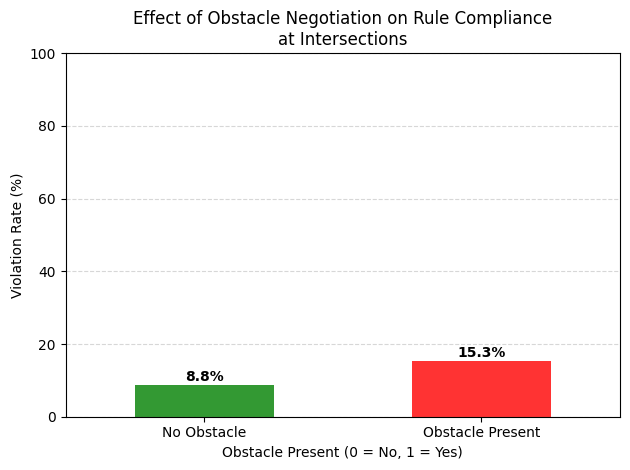

Violation rates:
obstacle_present
0     8.823529
1    15.306122


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate 200 intersection approaches
np.random.seed(42)
n = 200
data = pd.DataFrame({
    'obstacle_present': np.random.choice([0, 1], n, p=[0.5, 0.5]),  # 0=clear, 1=obstacle
    'distance_to_stop': np.random.uniform(0, 30, n),
    'initial_speed': np.random.uniform(5, 15, n)
})

# Rule: if vehicle is within 5m of stop line and obstacle present, negotiation often causes violation
# We'll define a violation if speed > 8 m/s within 5m of stop when obstacle present
data['violation'] = 0
data.loc[
    (data['obstacle_present'] == 1) &
    (data['distance_to_stop'] < 5) &
    (data['initial_speed'] > 8),
    'violation'
] = 1

# Also a small baseline violation even without obstacle (random)
data.loc[
    (data['obstacle_present'] == 0) &
    (data['distance_to_stop'] < 5) &
    (data['initial_speed'] > 12),  # higher threshold needed
    'violation'
] = 1

# Calculate violation rates
violation_rates = data.groupby('obstacle_present')['violation'].mean() * 100

# Plot
colors = ['green', 'red']
violation_rates.plot(kind='bar', color=colors, alpha=0.8)
plt.title('Effect of Obstacle Negotiation on Rule Compliance\nat Intersections')
plt.xlabel('Obstacle Present (0 = No, 1 = Yes)')
plt.ylabel('Violation Rate (%)')
plt.xticks(ticks=[0,1], labels=['No Obstacle', 'Obstacle Present'], rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on bars
for i, v in enumerate(violation_rates):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Violation rates:")
print(violation_rates.to_string())

### Summary

This synthetic example demonstrates the analysis pipeline end-to-end: constructing a dataset, defining a rule-compliance condition, computing violation rates, and visualising them. Because the rule is injected by design, the numbers here are illustrative of the method rather than evidence. The empirical pattern — obstacle presence near complex/occluded intersections coinciding with higher rule-compliance failures — is documented in the write-up above, based on the real AV perception-annotation work.